In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = psycopg2.connect(
    host="localhost",
    database="IPL",    # replace with your database name
    user="postgres",             # replace with your username
    password="12345qwerty"     # replace with your password
)

print("Connection Successful!")

Connection Successful!


In [2]:
matches = pd.read_sql_query("SELECT * FROM matches", conn)
deliveries = pd.read_sql_query("SELECT * FROM deliveries", conn)

print(matches.shape)
print(deliveries.shape)

C:\Users\hp\AppData\Local\Temp\ipykernel_20224\3585995323.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  matches = pd.read_sql_query("SELECT * FROM matches", conn)
C:\Users\hp\AppData\Local\Temp\ipykernel_20224\3585995323.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  deliveries = pd.read_sql_query("SELECT * FROM deliveries", conn)


(38, 23)
(17477, 19)


C:\Users\hp\AppData\Local\Temp\ipykernel_20224\1979071603.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


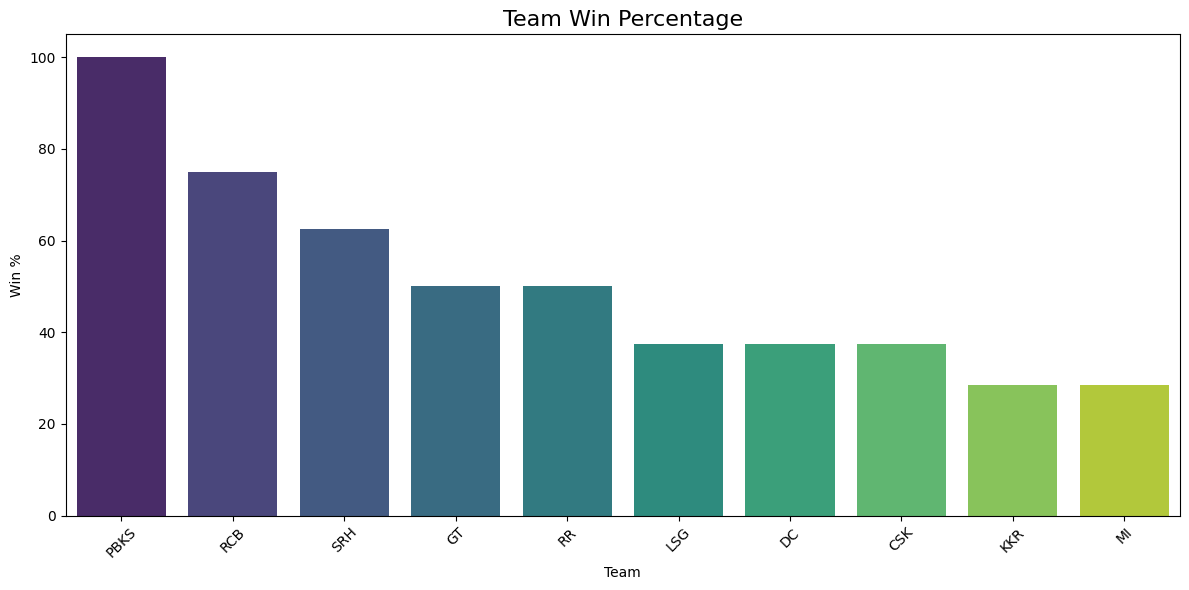

In [3]:
query = """
SELECT team,
ROUND(SUM(CASE WHEN match_winner = team THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS win_pct
FROM (
    SELECT team1 AS team, match_winner FROM matches
    UNION ALL
    SELECT team2 AS team, match_winner FROM matches
) AS all_matches
WHERE match_winner IS NOT NULL
GROUP BY team ORDER BY win_pct DESC
"""
df = pd.read_sql_query(query, conn)

plt.figure(figsize=(12,6))
sns.barplot(data=df, x='team', y='win_pct',hue='team', palette='viridis',legend=False)
plt.title('Team Win Percentage', fontsize=16)
plt.xlabel('Team')
plt.ylabel('Win %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('team_win_percentage.png')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_20224\2391178480.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


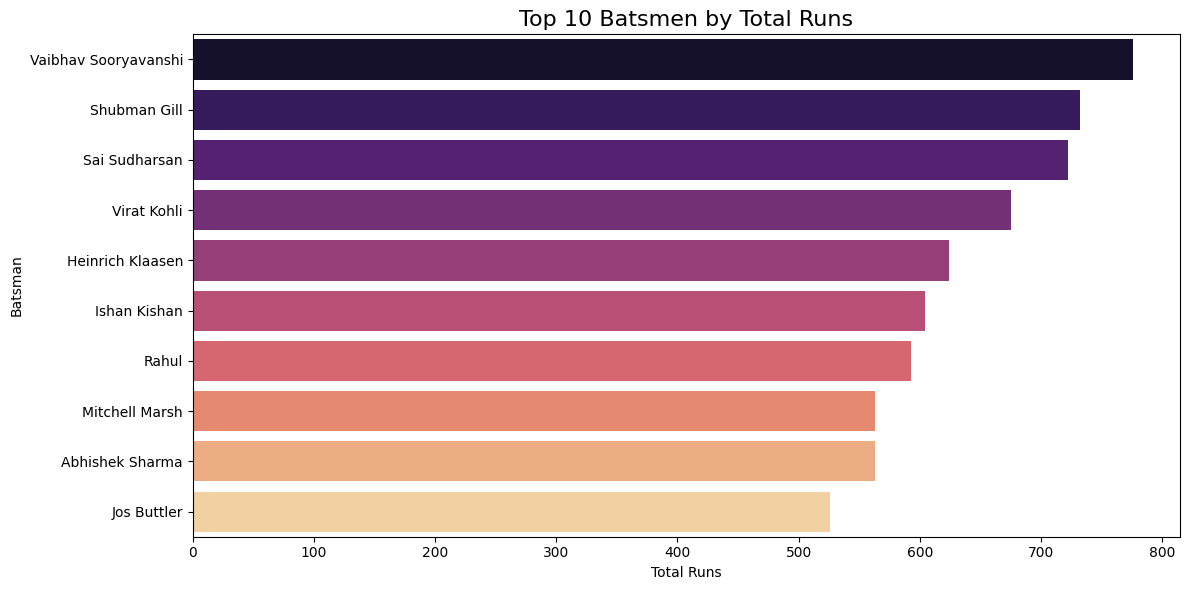

In [4]:
query = """
SELECT striker, SUM(runs_of_bat) AS total_runs
FROM deliveries WHERE wide = 0
GROUP BY striker ORDER BY total_runs DESC LIMIT 10
"""
df = pd.read_sql_query(query, conn)

plt.figure(figsize=(12,6))
sns.barplot(data=df, x='total_runs', y='striker', hue='striker' , palette='magma',legend=False)
plt.title('Top 10 Batsmen by Total Runs', fontsize=16)
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.savefig('top_batsmen.png')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_20224\2201406671.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


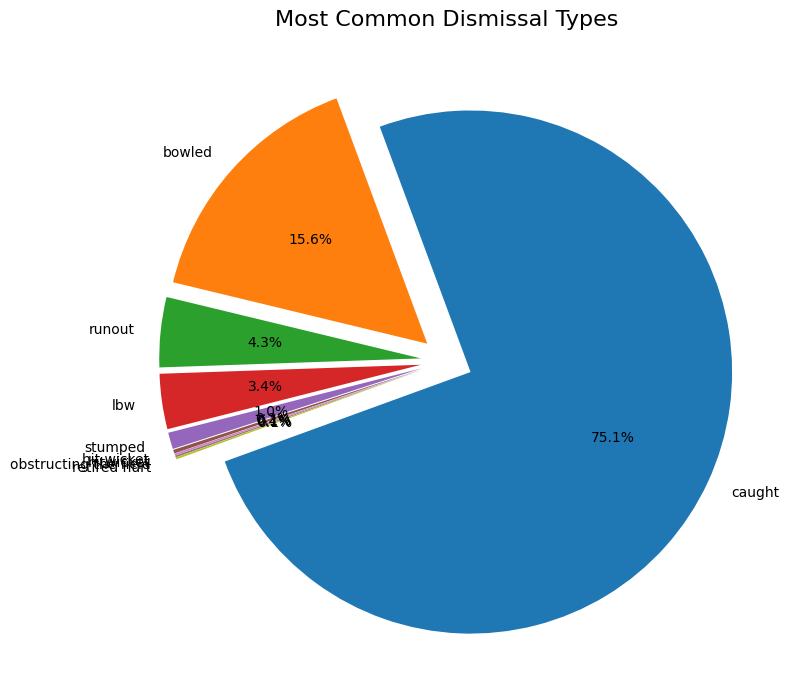

In [5]:
query = """
SELECT wicket_type, COUNT(*) AS total
FROM deliveries
WHERE wicket_type IS NOT NULL AND wicket_type != ''
GROUP BY wicket_type ORDER BY total DESC
"""
df = pd.read_sql_query(query, conn)
explode=[0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1]
plt.figure(figsize=(8,8))
plt.pie(df['total'], labels=df['wicket_type'],explode=explode ,autopct='%1.1f%%', startangle=200)
plt.title('Most Common Dismissal Types', fontsize=16)
plt.tight_layout()
plt.savefig('dismissal_types.png')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_20224\3317295237.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


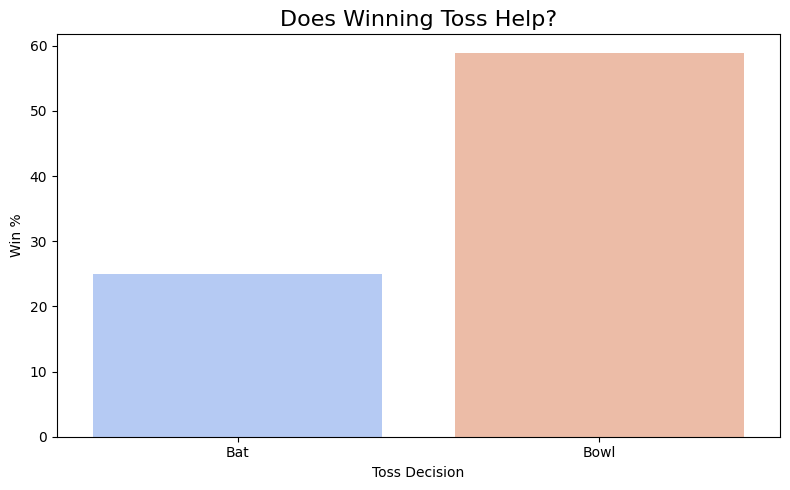

In [6]:
query = """
SELECT toss_decision,
ROUND(SUM(CASE WHEN toss_winner = match_winner THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS win_pct
FROM matches WHERE match_result = 'completed'
GROUP BY toss_decision
"""
df = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,5))
sns.barplot(data=df, x='toss_decision', y='win_pct',hue='toss_decision', palette='coolwarm',legend=False)
plt.title('Does Winning Toss Help?', fontsize=16)
plt.xlabel('Toss Decision')
plt.ylabel('Win %')
plt.tight_layout()
plt.savefig('toss_impact.png')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_20224\852810219.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


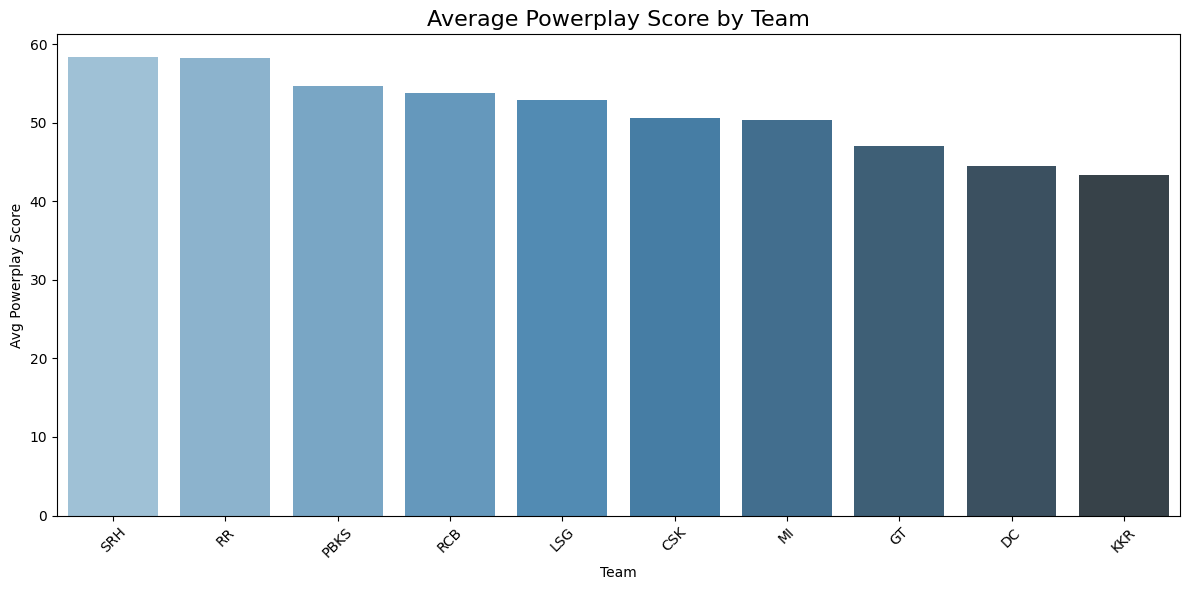

In [7]:
query = """
SELECT batting_team, ROUND(AVG(team_pp_runs), 2) AS avg_pp_score
FROM (
    SELECT match_no, batting_team, SUM(runs_of_bat + extras) AS team_pp_runs
    FROM deliveries WHERE over BETWEEN 1 AND 6
    GROUP BY match_no, batting_team
) AS pp
GROUP BY batting_team ORDER BY avg_pp_score DESC
"""
df = pd.read_sql_query(query, conn)

plt.figure(figsize=(12,6))
sns.barplot(data=df, x='batting_team', y='avg_pp_score',hue='batting_team', palette='Blues_d',legend=False)
plt.title('Average Powerplay Score by Team', fontsize=16)
plt.xlabel('Team')
plt.ylabel('Avg Powerplay Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('powerplay_scores.png')
plt.show()